# Image denoising with a conditional DDPM

This tutorial trains `DenoisingDDPM` to restore real DeepLense gravitational-lens images corrupted by blur and Gaussian noise (PLAN.md item B1). B1 has no dedicated astronomy reference dataset; it reuses the blur-plus-Gaussian-noise corruption recipe from family C's super-resolution repos (`Super_Resolution_Pranath_Reddy/src/PreProcessData.py`: per-image Gaussian blur with sigma drawn from `[0.5, 2.5]`, then Gaussian noise with sigma drawn from `[0.01, 0.1]`), applied here to the same real lens images used by `ddpm_class_conditional.ipynb`. The model output is compared with the corrupted input using PSNR and SSIM, the pair reported by the reference repos' own results tables.

## What you will do

1. Load real lens images and apply a known corruption.
2. Train a diffusion model conditioned on the corrupted image.
3. Compare reconstruction quality and inspect the restored images.

In [1]:
from pathlib import Path
import sys
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download
from torch.nn import functional
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import functional as image_functional
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent))
from astrogen.tasks import DenoisingDDPM
from examples.evaluation.metrics import psnr, ssim

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = Path.cwd().parent / "data" / "deeplense"
REPO_ID = "nelm/gsoc-2026-deeplense-dataset"
CLASS_FOLDERS = ["no", "vort", "sphere"]
IMAGE_SIZE = 64
torch.manual_seed(0)
print(f"Using {DEVICE}")

Could not find the bitsandbytes CUDA binary at PosixPath('/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/bitsandbytes/libbitsandbytes_cuda128.so')


The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.


Using cuda


## Prepare paired clean and corrupted images

Clean targets are real lens images (all three DeepLense classes pooled, since denoising is class-agnostic). Blur removes high-frequency detail while Gaussian noise adds stochastic corruption; both tensors stay in `[-1, 1]`.

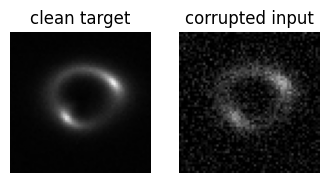

In [2]:
def _extract_subset(cache_dir: Path, split: str, count_per_class: int) -> None:
    zip_path = hf_hub_download(REPO_ID, "dataset.zip", repo_type="dataset")
    with zipfile.ZipFile(zip_path) as archive:
        members = []
        for folder in CLASS_FOLDERS:
            existing_dir = cache_dir / "dataset" / split / folder
            existing = len(list(existing_dir.glob("*.npy"))) if existing_dir.exists() else 0
            if existing >= count_per_class:
                continue
            prefix = f"dataset/{split}/{folder}/"
            members += sorted(n for n in archive.namelist() if n.startswith(prefix) and n.endswith(".npy"))[:count_per_class]
        if members:
            archive.extractall(cache_dir, members=members)

def load_split(split: str, count_per_class: int) -> torch.Tensor:
    _extract_subset(DATA_ROOT, split, count_per_class)
    images = []
    for folder in CLASS_FOLDERS:
        files = sorted((DATA_ROOT / "dataset" / split / folder).glob("*.npy"))[:count_per_class]
        images.append(torch.from_numpy(np.stack([np.load(f) for f in files])).float())
    images = functional.interpolate(torch.cat(images), size=IMAGE_SIZE, mode="bilinear")
    return (images * 2 - 1).clamp(-1, 1)

def corrupt(clean: torch.Tensor) -> torch.Tensor:
    """Per-image Gaussian blur + Gaussian noise, following the reference recipe
    (``Super_Resolution_Pranath_Reddy/src/PreProcessData.py``): blur sigma in
    ``[0.5, 2.5]`` with OpenCV's ``ksize = 2 * round(3 * sigma) + 1``, then
    noise sigma in ``[0.01, 0.1]`` (doubled here since the reference adds
    noise in ``[0, 1]`` before its own `2x - 1` rescale to this notebook's
    ``[-1, 1]`` space)."""
    corrupted = []
    for image in clean:
        blur_sigma = torch.empty(1).uniform_(0.5, 2.5).item()
        kernel_size = 2 * round(3 * blur_sigma) + 1
        blurred = image_functional.gaussian_blur(image.unsqueeze(0), kernel_size, blur_sigma)
        noise_sigma = 2 * torch.empty(1).uniform_(0.01, 0.1).item()
        corrupted.append((blurred + noise_sigma * torch.randn_like(blurred)).clamp(-1, 1))
    return torch.cat(corrupted)

train_clean = load_split("train", count_per_class=10_000)
val_clean = load_split("val", count_per_class=2_500)
train_corrupted, val_corrupted = corrupt(train_clean), corrupt(val_clean)

_, axes = plt.subplots(1, 2, figsize=(4, 2))
for axis, image, title in zip(axes, (train_clean[0], train_corrupted[0]), ("clean target", "corrupted input")):
    axis.imshow(image[0], cmap="gray", vmin=-1, vmax=1)
    axis.set_title(title)
    axis.axis("off")
plt.show()

## Train the restoration model

The model receives the corruption as its condition and learns to predict the clean target's diffusion noise. The loss is the standard DDPM noise-prediction objective.

DenoisingDDPM:   0%|          | 0/100 [00:00<?, ?it/s]

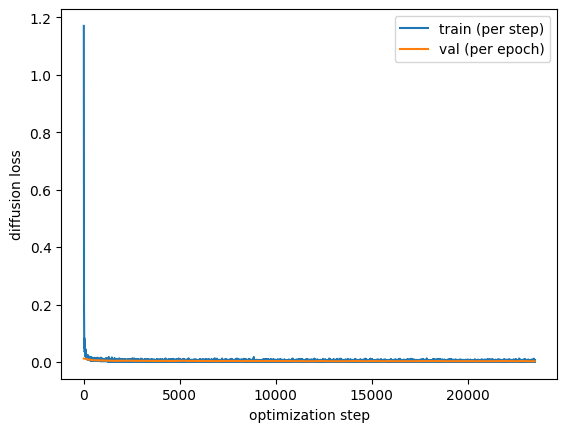

In [3]:
model = DenoisingDDPM(base_channels=32, timesteps=1_000).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
loader = DataLoader(TensorDataset(train_corrupted, train_clean), batch_size=128, shuffle=True)
train_losses, val_losses = [], []

progress = tqdm(range(100), desc="DenoisingDDPM")
for _ in progress:
    model.train()
    for batch_corrupted, batch_clean in loader:
        optimizer.zero_grad()
        loss = model(batch_corrupted.to(DEVICE), batch_clean.to(DEVICE))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        val_loss = model(val_corrupted.to(DEVICE), val_clean.to(DEVICE)).item()
    val_losses.append(val_loss)
    progress.set_postfix(train_loss=f"{train_losses[-1]:.4f}", val_loss=f"{val_loss:.4f}")

plt.plot(train_losses, label="train (per step)")
plt.plot(
    torch.linspace(0, len(train_losses) - 1, len(val_losses)), val_losses, label="val (per epoch)"
)
plt.xlabel("optimization step")
plt.ylabel("diffusion loss")
plt.legend()
plt.show()

## Evaluate against the input baseline

PSNR and SSIM measure error and structural similarity relative to the clean target: higher is better for both. Comparing against the corrupted input checks whether denoising improves on simply returning the observation.

DDPM       (500 val samples): PSNR 38.85 dB, SSIM 0.984
corrupted-input baseline:              PSNR 25.20 dB, SSIM 0.547


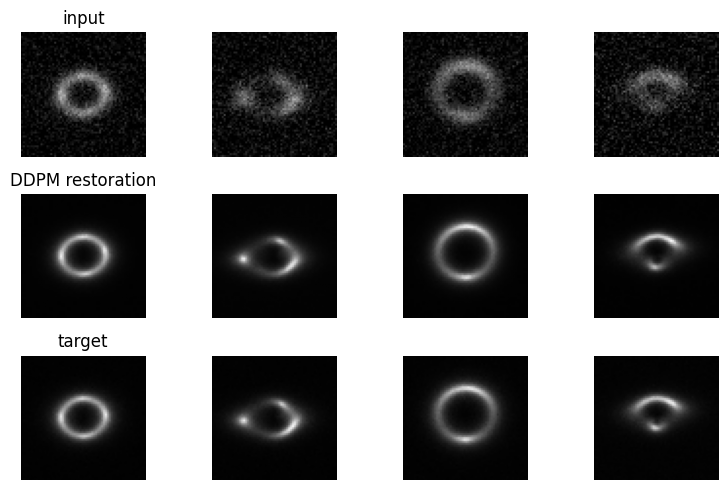

In [4]:
model.eval()
EVAL_COUNT = 500
VISUALIZE_COUNT = 4
holdout_clean = val_clean[:EVAL_COUNT].to(DEVICE)
holdout_corrupted = val_corrupted[:EVAL_COUNT].to(DEVICE)
with torch.no_grad():
    denoised = model.sample(holdout_corrupted)

print(f"DDPM       ({len(holdout_clean)} val samples): PSNR {psnr(denoised, holdout_clean):.2f} dB, SSIM {ssim(denoised, holdout_clean):.3f}")
print(f"corrupted-input baseline:              PSNR {psnr(holdout_corrupted, holdout_clean):.2f} dB, SSIM {ssim(holdout_corrupted, holdout_clean):.3f}")

_, axes = plt.subplots(3, VISUALIZE_COUNT, figsize=(8, 5))
for column in range(VISUALIZE_COUNT):
    for row, (image, title) in enumerate(zip(
        (holdout_corrupted[column], denoised[column], holdout_clean[column]),
        ("input", "DDPM restoration", "target"),
    )):
        axes[row, column].imshow(image[0].cpu(), cmap="gray", vmin=-1, vmax=1)
        axes[row, column].set_title(title if column == 0 else "")
        axes[row, column].axis("off")
plt.tight_layout()
plt.show()